In [1]:
import json
from collections import Counter
import pandas as pd

def analyze_language_balance(filepath):
    """
    Analyse un fichier JSONL pour compter la distribution des paires de langues.
    """
    pair_counter = Counter()

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                data = json.loads(line)
                # Extrait les clés de langue (ex: 'fra_Latn', 'ary_Arab')
                langs = sorted(list(data['translation'].keys()))
                
                if len(langs) == 2:
                    pair = f"{langs[0]} <-> {langs[1]}"
                    pair_counter[pair] += 1
            except (json.JSONDecodeError, KeyError, AttributeError):
                print(f"Attention : ligne mal formatée ou invalide ignorée : {line.strip()}")

    print("=== 1. Équilibre des Paires de Langues ===")
    if not pair_counter:
        print("Aucune paire de langue valide trouvée.")
        return

    # Afficher les résultats sous forme de tableau
    df = pd.DataFrame(pair_counter.items(), columns=['Paire de Langues', 'Nombre d\'exemples'])
    df = df.sort_values(by='Nombre d\'exemples', ascending=False).reset_index(drop=True)
    print(df)
    
    total = df["Nombre d'exemples"].sum()
    print(f"\nNombre total d'exemples : {total}")


analyze_language_balance('all_translations_dataset.jsonl')

=== 1. Équilibre des Paires de Langues ===
        Paire de Langues  Nombre d'exemples
0  ary_Arab <-> eng_Latn              31034
1  ary_Arab <-> fra_Latn              20870

Nombre total d'exemples : 51904



=== 2. Équilibre de la Longueur des Phrases ===
Statistiques descriptives sur la longueur des phrases :
       Longueur (mots)
count    103808.000000
mean         10.072885
std           9.142678
min           1.000000
25%           4.000000
50%           6.000000
75%          14.000000
max          62.000000


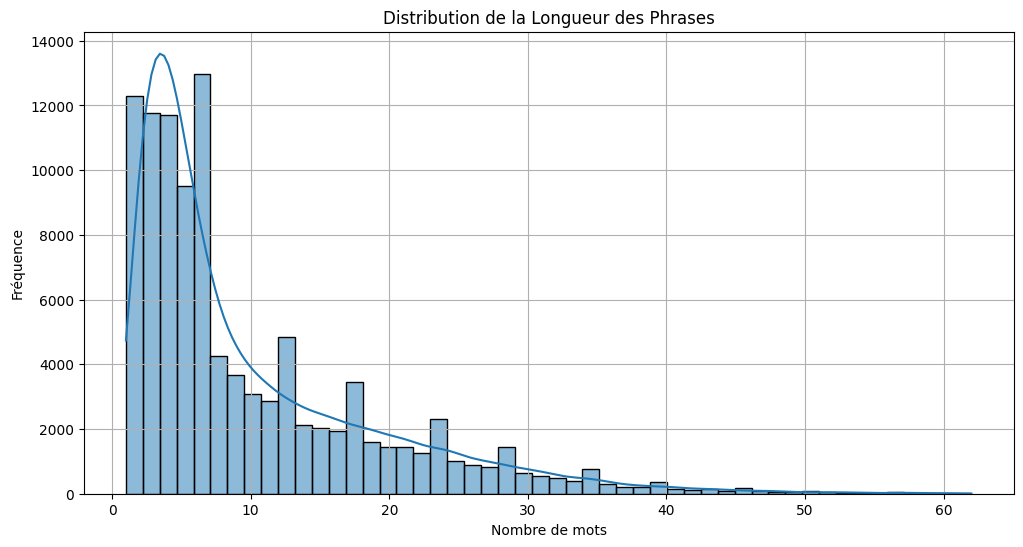

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_length_balance(filepath):
    """
    Analyse la distribution de la longueur des phrases (en nombre de mots).
    """
    lengths = {'source': [], 'target': []}

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                data = json.loads(line)
                texts = list(data['translation'].values())
                if len(texts) == 2:
                    # On ne sait pas qui est la source/cible, donc on les ajoute simplement
                    lengths['source'].append(len(texts[0].split()))
                    lengths['target'].append(len(texts[1].split()))
            except (json.JSONDecodeError, KeyError, AttributeError):
                continue
    
    print("\n=== 2. Équilibre de la Longueur des Phrases ===")
    if not lengths['source']:
        print("Aucune donnée de longueur à analyser.")
        return

    all_lengths = lengths['source'] + lengths['target']
    df_lengths = pd.DataFrame(all_lengths, columns=['Longueur (mots)'])
    
    print("Statistiques descriptives sur la longueur des phrases :")
    print(df_lengths.describe())
    
    # Visualisation
    plt.figure(figsize=(12, 6))
    sns.histplot(df_lengths['Longueur (mots)'], bins=50, kde=True)
    plt.title('Distribution de la Longueur des Phrases')
    plt.xlabel('Nombre de mots')
    plt.ylabel('Fréquence')
    plt.grid(True)
    plt.show()

analyze_length_balance('all_translations_dataset.jsonl')